<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Data from Kaggle

In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")

print("Path to dataset files:", path)

100%|██████████| 199M/199M [00:01<00:00, 147MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/versions/2


In [ ]:
import os

print(os.listdir(path))

['The IQ-OTHNCCD lung cancer dataset', 'Test cases']


In [ ]:
train_path = os.path.join(path, "The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset")
print(os.listdir(train_path))

['Normal cases', 'Malignant cases', 'IQ-OTH_NCCD lung cancer dataset.txt', 'Bengin cases']


## Data Augmentation

In [ ]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

base_dataset = ImageFolder(root=train_path, transform=None)
base_train = ImageFolder(root=train_path, transform=train_transform)
base_test  = ImageFolder(root=train_path, transform=test_transform)

In [ ]:
len(base_train)

1097

Bengin cases


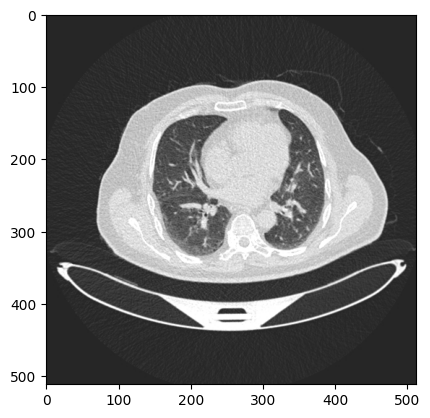

In [ ]:
import matplotlib.pyplot as plt

original_image, original_label = base_dataset[0]
plt.imshow(original_image)
print(base_dataset.classes[original_label])

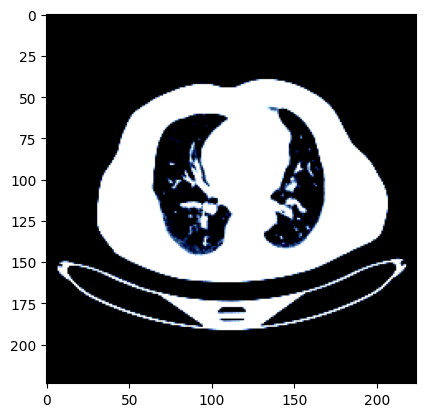

In [ ]:
transformed_image = test_transform(original_image)

plt.imshow(transformed_image.permute(1, 2, 0), cmap="gray")

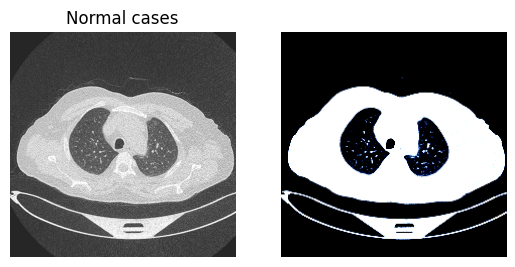

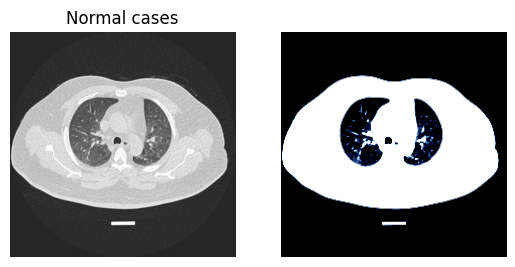

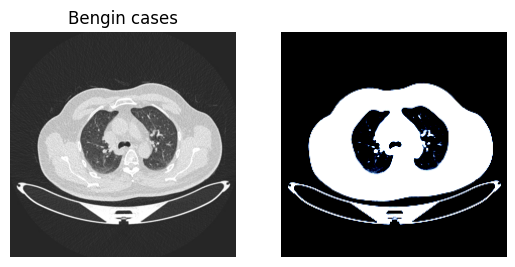

In [ ]:
import random
n = 3
for i in range(0, n):
  fig, ax = plt.subplots(1, 2)
  idx = random.randint(0, len(base_dataset))
  original_image, label = base_dataset[idx]
  ax[0].imshow(original_image)
  ax[0].set_title(base_dataset.classes[label])
  ax[0].axis("off")

  transformed_image = test_transform(original_image)
  ax[1].imshow(transformed_image.permute(1, 2, 0), cmap="gray")
  ax[1].axis("off")

### Reduce Dataset to Smaller Dataset

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# get index and label
labels = [label for _, label in base_dataset.samples]
indecies = list(range(len(base_dataset)))

# take 300 data randomly + stratified
# we don't use unselected data
selected_idx, unselected_idx = train_test_split(indecies, train_size=1000, stratify=labels, random_state=67)
selected_labels = [labels[i] for i in selected_idx]

# train test split
train_idx, test_idx = train_test_split(selected_idx, test_size=0.2, stratify=selected_labels, random_state=67)

In [ ]:
from torch.utils.data import DataLoader

# make subset of train and test
train_dataset = Subset(base_train, train_idx)
test_dataset  = Subset(base_test, test_idx)

# make the DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

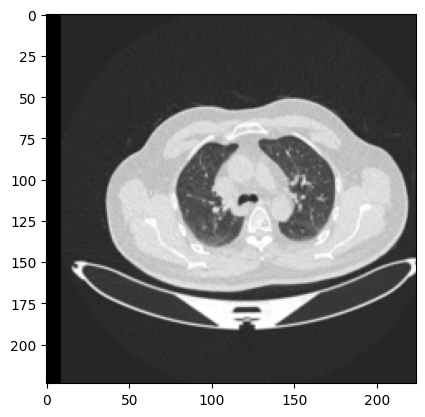

In [ ]:
import torchvision.transforms as transforms

# test_transform_1 = transforms.Compose([
#     transforms.Resize(size=(224,224)),
#     transforms.TrivialAugmentWide(num_magnitude_bins=50),
#     transforms.ToTensor()

# ])

img_transformed = test_transform_1(original_image)
plt.imshow(img_transformed.permute(1, 2, 0))

## 7. Built Model TinyVGG

In [ ]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*56*56,
                  out_features=output_shape)
    )
  def forward(self, x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x
    # return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [ ]:
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=3).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=3, bias=True)
  )
)

In [ ]:
image_batch, label_batch = next(iter(train_loader))
model_0(image_batch)

tensor([[-2.8374e-02,  4.6312e-02, -5.4814e-04],
        [-3.2580e-02,  5.5193e-02, -5.1017e-05],
        [-2.7190e-02,  4.6088e-02, -1.4800e-02],
        [-1.2041e-02,  6.0787e-02, -2.2630e-02],
        [-2.6283e-02,  5.8200e-02,  1.3672e-03],
        [-2.3357e-02,  4.7471e-02, -2.7108e-03],
        [-2.5935e-02,  5.2768e-02, -2.8389e-03],
        [-3.2855e-02,  3.1382e-02, -1.4518e-03],
        [-1.4422e-02,  4.9182e-02,  1.9717e-03],
        [-2.3064e-02,  4.2261e-02, -5.8334e-04],
        [-1.9837e-02,  5.4940e-02, -1.3807e-02],
        [-2.8479e-02,  4.7436e-02,  1.3930e-03],
        [-3.0132e-02,  4.9244e-02, -5.9099e-03],
        [-2.9642e-02,  4.4960e-02, -9.9751e-03],
        [-2.2272e-02,  6.7059e-02, -1.2867e-02],
        [-1.1454e-02,  4.9214e-02, -1.2722e-02]], grad_fn=<AddmmBackward0>)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model_0, input_size=[1, 3, 224, 224])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 10, 224, 224]         280
│    └─ReLU: 2-2                         [1, 10, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 10, 224, 224]         910
│    └─ReLU: 2-4                         [1, 10, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 10, 112, 112]         --
├─Sequential: 1-2                        [1, 10, 56, 56]           --
│    └─Conv2d: 2-6                       [1, 10, 112, 112]         910
│    └─ReLU: 2-7                         [1, 10, 112, 112]         --
│    └─Conv2d: 2-8                       [1, 10, 112, 112]         910
│    └─ReLU: 2-9                         [1, 10, 112, 112]         --
│    └─MaxPool2d: 2-10                   [1, 10, 56, 56]           --
├─Sequentia

In [ ]:
# create train_step()
def train_step(model, dataloader, loss_fn, optimizer, device=device):
  model.train()
  train_loss, train_acc = 0.0, 0.0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class==y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

# create test step
def test_step(model, dataloader, loss_fn, device=device):
  model.eval()
  test_loss, test_acc = 0.0, 0.0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()
      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [ ]:
# create training model fucntion

from tqdm.auto import tqdm
def train(model, train_loader, test_loader, loss_fn, optimizer, epochs=5, device=device):
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_loader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)
    test_loss, test_acc = test_step(model=model,
                                     dataloader=test_loader,
                                     loss_fn=loss_fn,
                                     device=device)
    print(
        f"Train loss: {train_loss:.3f}"
        f" | Train accuracy: {train_acc:.3f}"
        f" | Test loss: {test_loss:.3f}"
        f" | Test accuracy: {test_acc:.3f}"
    )
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [ ]:
torch.manual_seed(42)

epochs = 10
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(base_dataset.classes)).to(device)
loss_fn_0 = nn.CrossEntropyLoss()
optimizer_0 = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

from time import time
start_0 = time()

model_0_results = train(model=model_0,
                        train_loader=train_loader,
                        test_loader=test_loader,
                        optimizer=optimizer_0,
                        loss_fn=loss_fn_0,
                        epochs=epochs)
end_0 = time()

model_0_time = end_0 - start_0
print(model_0_time)

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
torch.save(model_0.state_dict(), f="model.pt")

In [ ]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [ ]:
def plot_loss_curves(results):
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))
  plt.subplot(121)
  plt.plot(epochs, loss, label="train loss")
  plt.plot(epochs, test_loss, label="test loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(122)
  plt.plot(epochs, accuracy, label="train accruacy")
  plt.plot(epochs, test_accuracy, label="test accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend();

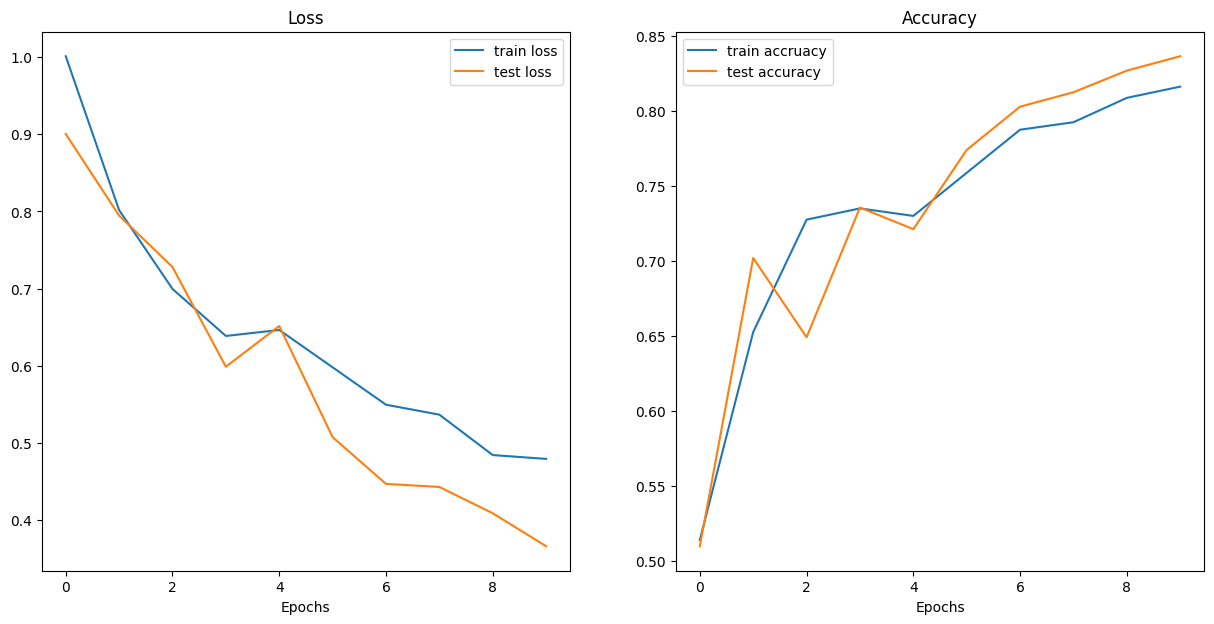

In [ ]:
plot_loss_curves(model_0_results)

## 11. Making a prediction on a custom image

In [ ]:
import random

random_idx = random.randint(0, len(base_dataset)-1)

custom_image, custom_label = base_dataset[random_idx]

custom_image = test_transform(custom_image)
model_0.eval()
with torch.inference_mode():
  custom_image_pred = model_0(custom_image.unsqueeze(dim=0))

class_idx = torch.softmax(custom_image_pred, dim=1).argmax(dim=1)
base_dataset.classes[class_idx], base_dataset.classes[custom_label]

('Malignant cases', 'Malignant cases')